In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
con = duckdb.connect('../data/airbnb.db')

# Directory for saving figures
os.makedirs('../reports/figures', exist_ok=True)

# Setting the plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Setup complete")

Setup complete


## Summary statistics & distributions

### Price distribution

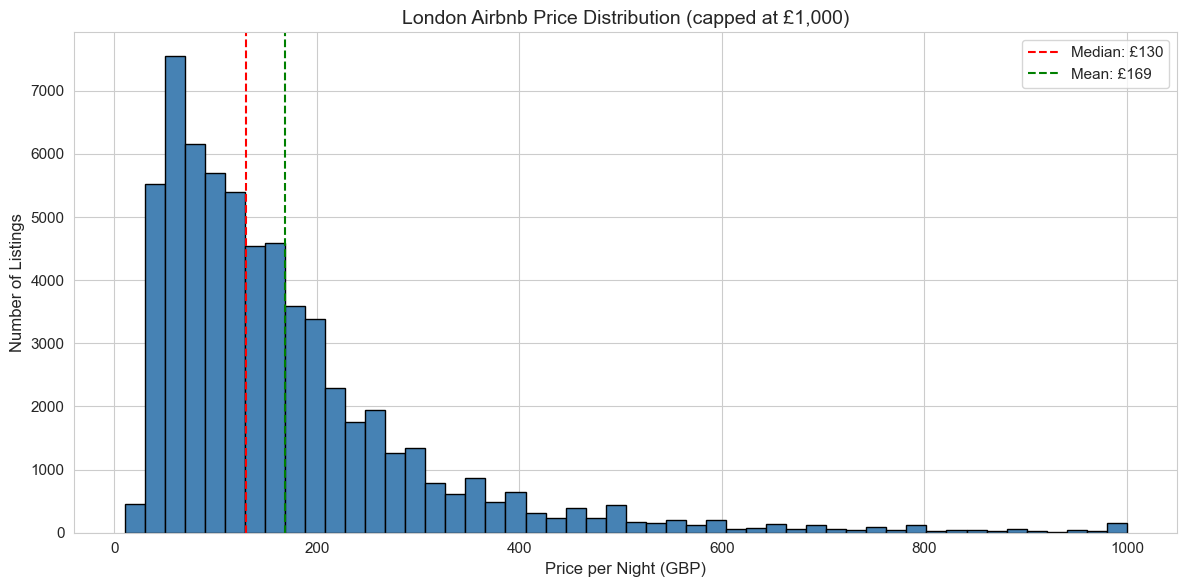

Saved: 01_price_distribution.png
Median: £130, Mean: £169


In [33]:
price_data = con.execute("""
    SELECT price FROM fact_listings 
    WHERE price IS NOT NULL AND price > 0 AND price <= 1000
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(price_data['price'], bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Price per Night (GBP)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.set_title('London Airbnb Price Distribution (capped at £1,000)', fontsize=14)
ax.axvline(price_data['price'].median(), color='red', linestyle='--', label=f'Median: £{price_data["price"].median():.0f}')
ax.axvline(price_data['price'].mean(), color='green', linestyle='--', label=f'Mean: £{price_data["price"].mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: 01_price_distribution.png")
print(f"Median: £{price_data['price'].median():.0f}, Mean: £{price_data['price'].mean():.0f}")

### Business interpretation 01 - Price distribution

Finding - Prices are heavily right-skewed with median at £130 but mean at £169.

What this means?
- The London Airbnb market has a long luxury tail where a small number of ultra-premium listings pull the average up significantly
- The typical host earns around £130/night, but the market supports a much wider range
- This is typical of two-sided marketplaces: budget options dominate volume, premium options dominate revenue

Actions for market participants,
- New hosts - Should price competitively around £100-150 to compete on volume
- Investors - Premium segment (£500+) is small but potentially high-margin
- Platform (Airbnb) - Should develop tiered search/filter to help guests navigate this wide range

### Price by room type

C:\Users\Yohan\AppData\Local\Temp\ipykernel_25152\112078522.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=room_prices, x='room_type', y='price', ax=ax, palette='Set2')


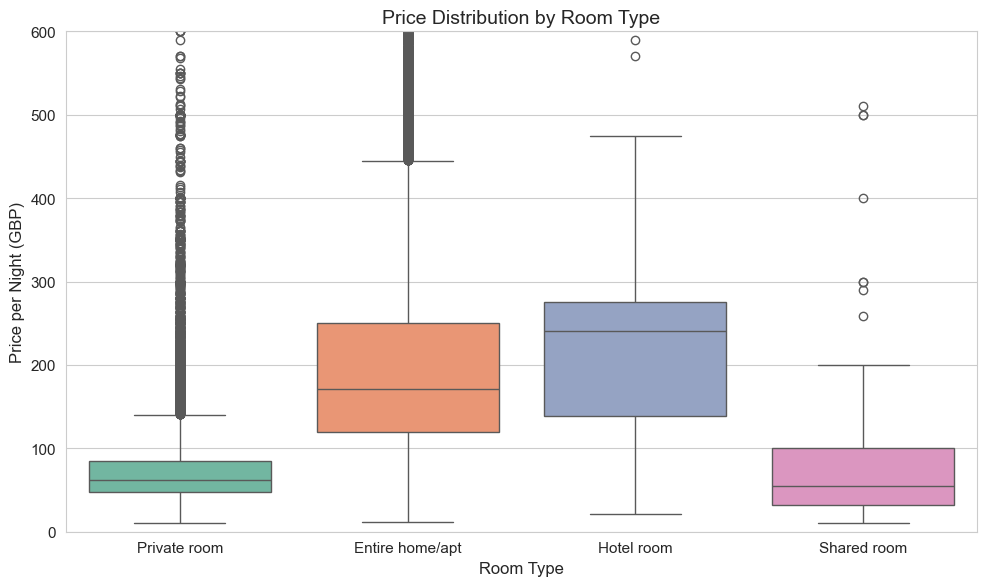

Saved: 02_price_by_room_type.png


In [34]:
room_prices = con.execute("""
    SELECT p.room_type, f.price
    FROM fact_listings f
    JOIN dim_property p ON f.property_id = p.property_id
    WHERE f.price IS NOT NULL AND f.price > 0 AND f.price <= 1000
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=room_prices, x='room_type', y='price', ax=ax, palette='Set2')
ax.set_xlabel('Room Type', fontsize=12)
ax.set_ylabel('Price per Night (GBP)', fontsize=12)
ax.set_title('Price Distribution by Room Type', fontsize=14)
ax.set_ylim(0, 600)
plt.tight_layout()
plt.savefig('../reports/figures/02_price_by_room_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: 02_price_by_room_type.png")

### Business interpretation 02 - Price by room type

Finding - Entire homes/apartments (median £170) command 2.5x the price of private rooms (median £60). Hotel rooms premium further at £240 median.

What this means?
- Privacy premium is substantial - guests pay 150%+ more for exclusive space
- The hotel room category (188 listings) competes with actual hotels and prices accordingly
- Shared rooms are a true budget option at ~£55 median, attracting cost-sensitive travelers

Actions for market participants,
- Casual hosts - Private rooms offer best ROI for low-effort hosting
- Professional operators - Entire home investments yield 2-3x revenue per listing
- Platform - Should highlight "good value" private rooms to budget travelers

### Availability distribution

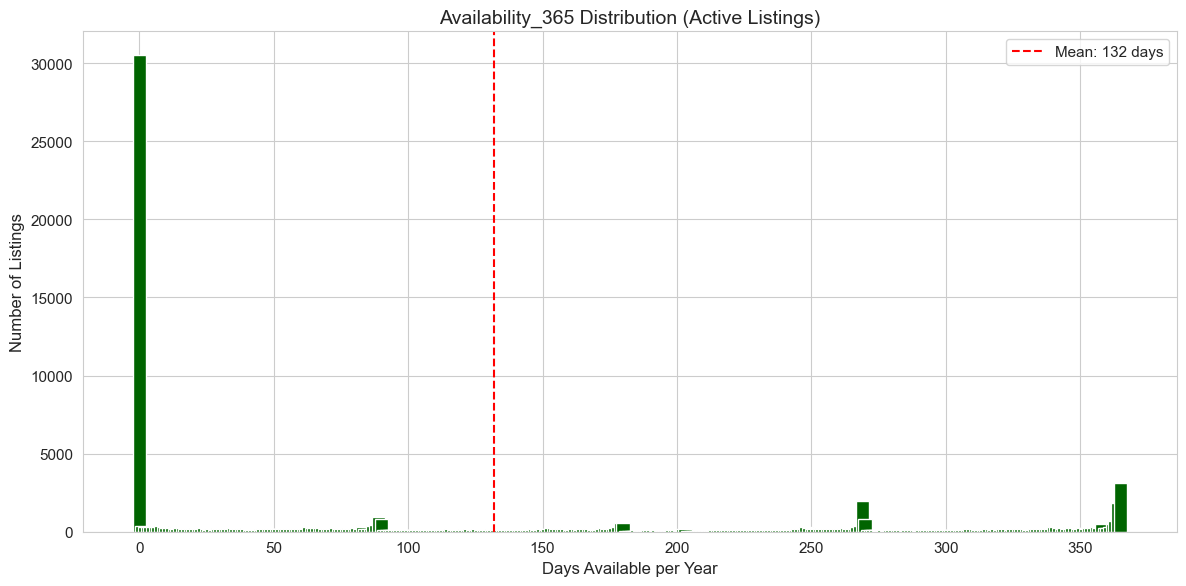

 Saved: 03_availability_distribution.png


In [40]:
availability = con.execute("""
    SELECT 
        availability_365,
        COUNT(*) as listing_count
    FROM fact_listings
    WHERE is_active = TRUE
    GROUP BY availability_365
    ORDER BY availability_365
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(availability['availability_365'], availability['listing_count'], color='darkgreen', width=5)
ax.set_xlabel('Days Available per Year', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.set_title('Availability_365 Distribution (Active Listings)', fontsize=14)
ax.axvline(132, color='red', linestyle='--', label='Mean: 132 days')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_availability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: 03_availability_distribution.png")

### Business Interpretation 03 - Availability patterns

Finding - Extreme bimodal distribution identified with 30,000+ listings have 0 days available, while a smaller cluster sits at 365 days (always available). Most listings cluster at these two extremes rather than the middle.

What this means?

- The London Airbnb market is bifurcated into two distinct host behaviors: "off" (0 days) and "always on" (365 days)
- Listings at 0 days are likely blocked, booked solid, or temporarily delisted yet not permanently inactive
- The 365-day cluster represents professional/commercial operators who treat STR as a business
- Very few listings sit in the middle among the 100-200 days regions for example, which is suggesting hosts either go all-in or stay casual as well

Actions for market participants,

- New hosts - Avoid 0 availability which seems like inactive listing. Therefore aim for 180+ days to build reputation
- Investors - High-availability listings (300+ days) are investment-grade; 365-day hosts are the commercial segment
- Platform (Airbnb) - Should investigate why 30K+ listings show 0 availability and search ranking impact

## b) Geographic & spatial analysis 

### Listings by neighbourhood

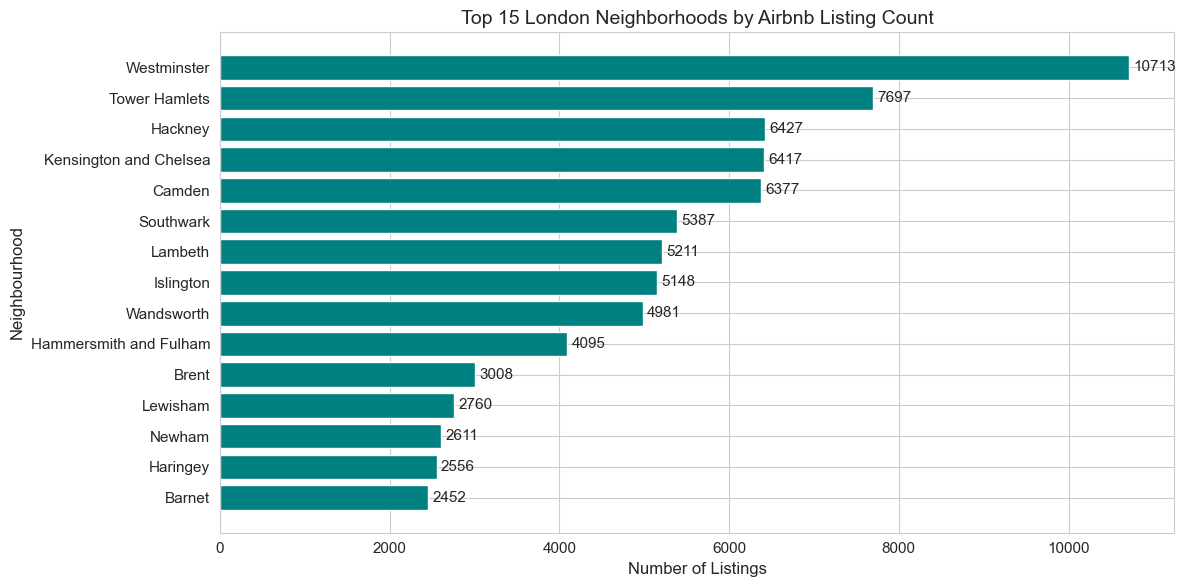

 Saved: 04_listings_by_neighborhood.png


In [35]:
nb_counts = con.execute("""
    SELECT loc.neighbourhood, loc.listing_count
    FROM dim_location loc
    ORDER BY loc.listing_count DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(nb_counts['neighbourhood'][::-1], nb_counts['listing_count'][::-1], color='teal')
ax.set_xlabel('Number of Listings', fontsize=12)
ax.set_ylabel('Neighbourhood', fontsize=12)
ax.set_title('Top 15 London Neighborhoods by Airbnb Listing Count', fontsize=14)
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig('../reports/figures/04_listings_by_neighborhood.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: 04_listings_by_neighborhood.png")

### Business interpretation 04 - Listing density by neighborhood

Finding - Westminster alone hosts 10,713 listings (11% of all London supply). Top 3 neighborhoods account for ~30% of market.

What this means
- Extreme geographic concentration - London Airbnb is essentially a central London phenomenon
- Tower Hamlets (7,697) and Hackney (6,427) reflect the "East London" trend toward short-term lets
- Peripheral boroughs (Barnet with 2,452) have 4x fewer listings, indicating untapped supply or lower tourist demand

Actions for market participants,
- Hosts - Entering Westminster is highly competitive; consider emerging neighborhoods
- Regulators - 30% concentration in 3 neighborhoods may warrant policy attention
- Investors - Outer boroughs represent growth opportunity as central supply saturates

### Average price by neighbourhood

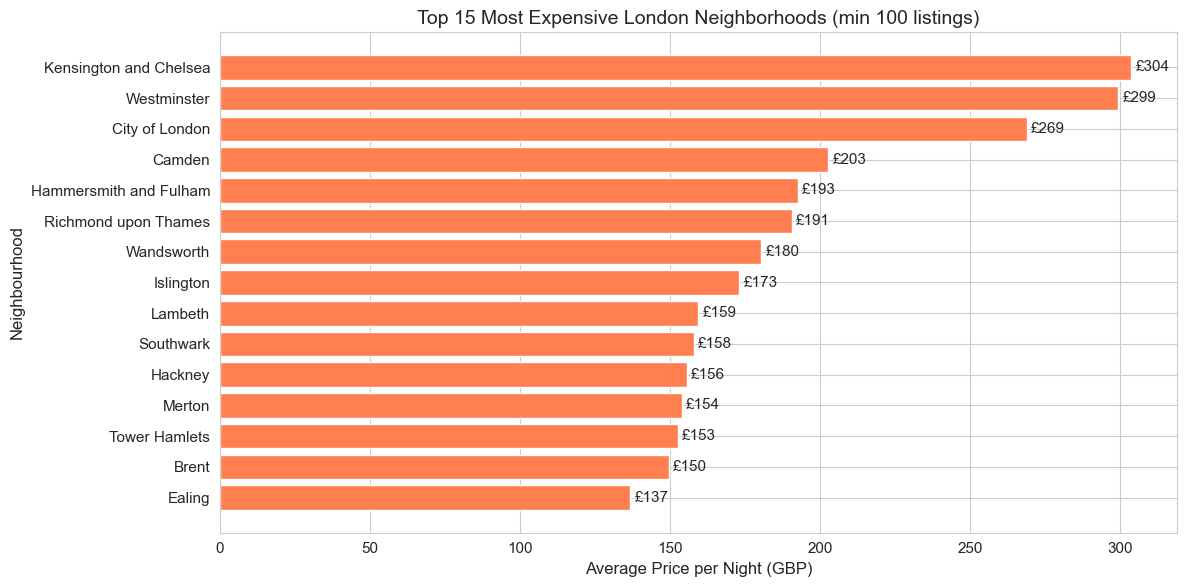

 Saved: 05_price_by_neighborhood.png


In [36]:
nb_prices = con.execute("""
    SELECT 
        loc.neighbourhood,
        ROUND(AVG(f.price), 2) as avg_price,
        COUNT(f.listing_id) as listing_count
    FROM fact_listings f
    JOIN dim_location loc ON f.location_id = loc.location_id
    WHERE f.price IS NOT NULL AND f.price > 0
    GROUP BY loc.neighbourhood
    HAVING COUNT(f.listing_id) >= 100
    ORDER BY avg_price DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(nb_prices['neighbourhood'][::-1], nb_prices['avg_price'][::-1], color='coral')
ax.set_xlabel('Average Price per Night (GBP)', fontsize=12)
ax.set_ylabel('Neighbourhood', fontsize=12)
ax.set_title('Top 15 Most Expensive London Neighborhoods (min 100 listings)', fontsize=14)
ax.bar_label(bars, padding=3, fmt='£%.0f')
plt.tight_layout()
plt.savefig('../reports/figures/05_price_by_neighborhood.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: 05_price_by_neighborhood.png")

### Business interpretation 05 - Geographic pricing gradient

Finding - Clear pricing gradient from central to outer London. Kensington & Chelsea (£304) commands 2.2x Ealing (£137).

What this means?
- Location is the single strongest price driver which outperforms room type, amenities, etc.
- The £100+ premium for central London reflects tourism density and business travel
- Ealing at £137 is still significantly above the overall median (£130), showing even outer London commands Airbnb-premium pricing

Actions for market participants,
- Buyers/Investors - Properties in K&C, Westminster, City of London generate 2x revenue
- Pricing strategy - New listings should benchmark against same-neighborhood median, not city average
- Platform - Should surface "luxury neighborhood" badges for premium pricing visibility

## c) Temporal & seasonal trends

### Reviews over time

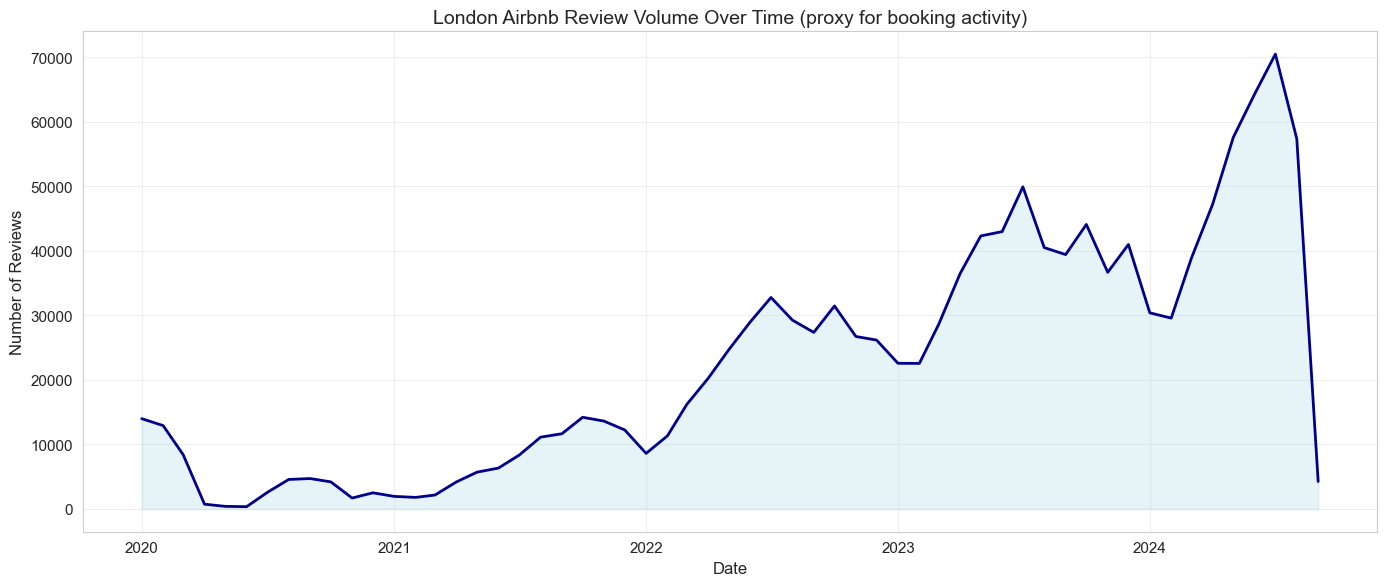

 Saved: 06_review_trend.png


In [37]:
review_trend = con.execute("""
    SELECT 
        EXTRACT(year FROM date) as year,
        EXTRACT(month FROM date) as month,
        COUNT(*) as review_count
    FROM reviews
    WHERE date >= '2020-01-01'
    GROUP BY year, month
    ORDER BY year, month
""").df()

review_trend['date'] = pd.to_datetime(review_trend[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(review_trend['date'], review_trend['review_count'], color='darkblue', linewidth=2)
ax.fill_between(review_trend['date'], review_trend['review_count'], alpha=0.3, color='lightblue')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('London Airbnb Review Volume Over Time (proxy for booking activity)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/06_review_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: 06_review_trend.png")

### Business interpretation 06 - Review volume trend (Booking Demand Proxy)

Finding - Review volume dropped from ~14K/month (early 2020) to near-zero (mid-2020), recovered strongly, and now exceeds 70K/month.

What this means?
- COVID impact was severe but temporary, 6-month crash, then 18-month recovery
- Current booking demand (70K reviews/month) is ~5x the early 2020 baseline, suggesting London Airbnb has fully recovered and grown
- The growth trajectory is steep, indicating market expansion, not just recovery

Actions for market participants,
- Investors - Strong upward demand justifies continued investment in London STR
- Hosts - High competition means differentiation (quality, location) is essential
- Platform - Should invest in supply-side growth to meet rising demand

### Host tenure vs price

 Host Tenure Distribution:
         tenure_category  host_count  avg_years
         Mid (2-5 years)       10239        3.3
Established (5-10 years)       21328        8.7
     Veteran (10+ years)       25451       12.3


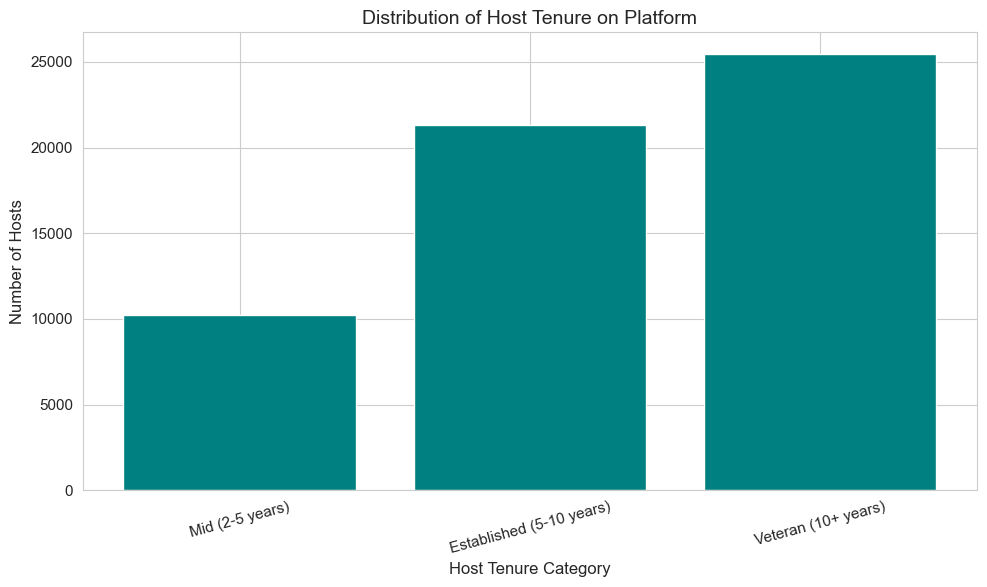

In [41]:
tenure_pricing = con.execute("""
    SELECT 
        CASE 
            WHEN host_tenure_years < 2 THEN 'New (<2 years)'
            WHEN host_tenure_years BETWEEN 2 AND 5 THEN 'Mid (2-5 years)'
            WHEN host_tenure_years BETWEEN 5 AND 10 THEN 'Established (5-10 years)'
            ELSE 'Veteran (10+ years)'
        END as tenure_category,
        COUNT(*) as host_count,
        ROUND(AVG(host_tenure_years), 1) as avg_years
    FROM dim_host
    WHERE host_tenure_years IS NOT NULL
    GROUP BY tenure_category
    ORDER BY avg_years
""").df()

print(" Host Tenure Distribution:")
print(tenure_pricing.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(tenure_pricing['tenure_category'], tenure_pricing['host_count'], color='teal')
ax.set_xlabel('Host Tenure Category', fontsize=12)
ax.set_ylabel('Number of Hosts', fontsize=12)
ax.set_title('Distribution of Host Tenure on Platform', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/07_host_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

### Business interpretation 07 - Host tenure

Finding - Veteran hosts (10+ years) are the largest segment with 25,000, followed by Established (5-10 years) with 21,000, with Mid-tenure (2-5 years) at only 10,000. New hosts (<2 years) are notably absent from this chart.

What this means?

- Survivorship bias is evident as we're only seeing hosts who survived to 2+ years
- The platform has strong host retention for those who make it past 2 years
- London has a mature host base where most active hosts have been here 5+ years
- The gap at 2-5 years suggests either high early churn or that early-tenure data is incomplete

Actions for market participants,

- New hosts (<2 years) - The data suggests early years are challenging so expect high attrition risk
- Platform - Should investigate why fewer hosts exist in the 2-5 year window on whether they are an onboarding issue?
- Investors - Veteran hosts represent stable, experienced supply worth partnering with
- Regulators - Mature host base means established networks, harder for new entrants

## d) Host & Supply-side analysis

### Listings per host

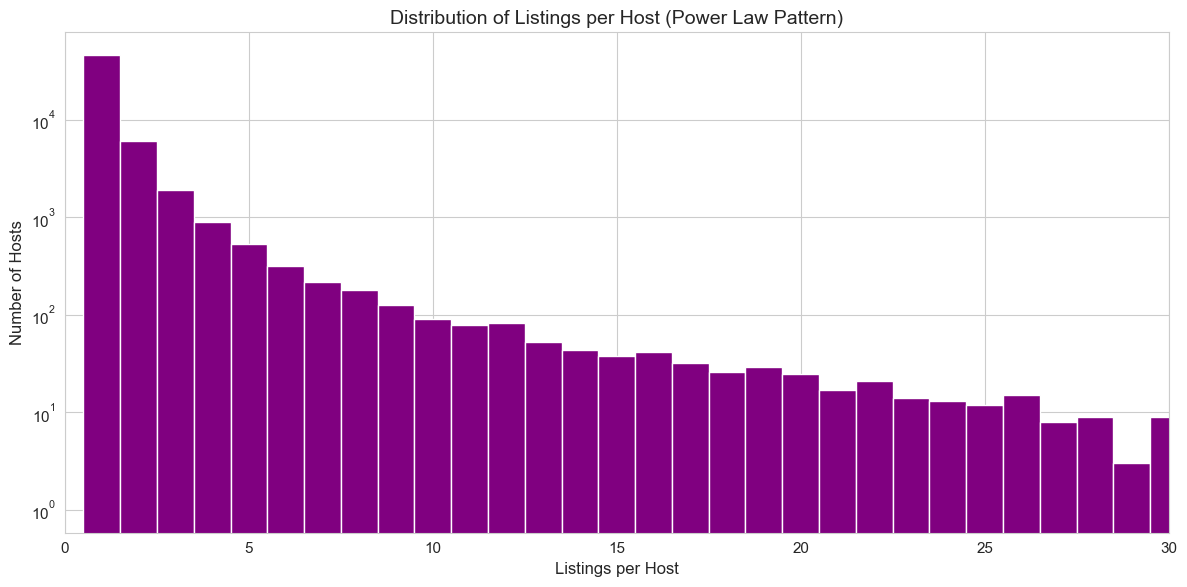

 Saved: 08_listings_per_host.png

 80.6% of hosts have only 1 listing (casual hosts)


In [38]:
host_distribution = con.execute("""
    SELECT calculated_host_listings_count as listings_per_host,
        COUNT(*) as host_count
    FROM dim_host
    WHERE calculated_host_listings_count IS NOT NULL
    GROUP BY calculated_host_listings_count
    ORDER BY calculated_host_listings_count
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(host_distribution['listings_per_host'], host_distribution['host_count'], color='purple', width=1.0)
ax.set_xlabel('Listings per Host', fontsize=12)
ax.set_ylabel('Number of Hosts', fontsize=12)
ax.set_title('Distribution of Listings per Host (Power Law Pattern)', fontsize=14)
ax.set_xlim(0, 30)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../reports/figures/08_listings_per_host.png', dpi=300, bbox_inches='tight')
plt.show()

# Concentration metric
total_hosts = host_distribution['host_count'].sum()
hosts_1_listing = host_distribution[host_distribution['listings_per_host'] == 1]['host_count'].sum()
single_listing_pct = (hosts_1_listing / total_hosts) * 100
print(f" Saved: 08_listings_per_host.png")
print(f"\n {single_listing_pct:.1f}% of hosts have only 1 listing (casual hosts)")

### Business interpretation 08 - Power law distribution of hosts

Finding - 80.6% of hosts have only 1 listing. A tiny fraction controls 10+ listings (commercial operators).

What this means?
- London Airbnb is predominantly casual hosting - individuals renting out spare rooms or second homes
- The long right tail represents commercial operators (property management companies, professional STR investors)
- This dual market structure means platform rules/policies must accommodate both segments differently

Actions for market participants,
- Casual hosts (1 listing) - Compete on personal touch, unique properties
- Commercial operators (10+ listings) - Compete on efficiency, professional service
- Regulators - Should distinguish between casual and commercial for policy purposes

### Superhost pricing

 Superhost vs Non-Superhost:
superhost_status  listing_count  avg_price  avg_rating  avg_reviews
               t          15117     178.82        4.85         47.7
         unknown           1180     183.72        4.61         35.5
               f          46845     185.00        4.60         16.2


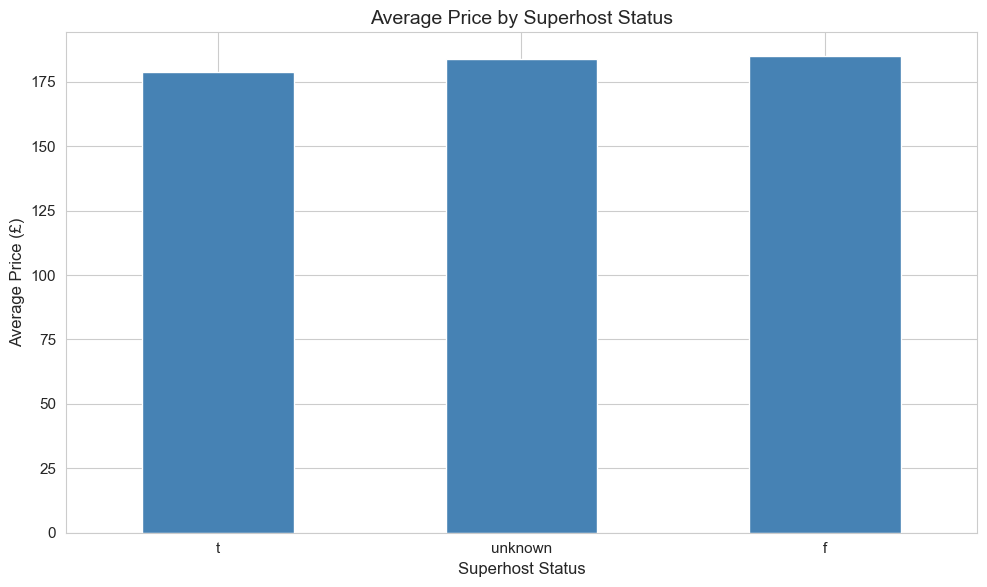

In [42]:
superhost_pricing = con.execute("""
    SELECT 
        h.superhost_status,
        COUNT(f.listing_id) as listing_count,
        ROUND(AVG(f.price), 2) as avg_price,
        ROUND(AVG(f.review_scores_rating), 2) as avg_rating,
        ROUND(AVG(f.number_of_reviews), 1) as avg_reviews
    FROM fact_listings f
    JOIN dim_host h ON f.host_id = h.host_id
    WHERE f.is_active = TRUE AND f.price IS NOT NULL AND f.price > 0
    GROUP BY h.superhost_status
    ORDER BY avg_rating DESC NULLS LAST
""").df()

print(" Superhost vs Non-Superhost:")
print(superhost_pricing.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
superhost_pricing.plot(kind='bar', x='superhost_status', y='avg_price', ax=ax, color='steelblue', legend=False)
ax.set_ylabel('Average Price (£)', fontsize=12)
ax.set_xlabel('Superhost Status', fontsize=12)
ax.set_title('Average Price by Superhost Status', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/09_superhost_pricing.png', dpi=300, bbox_inches='tight')
plt.show()

### Business interpretation 09 - Superhost vs non-superhost pricing

Finding - All three superhost categories (t, unknown, f) have nearly identical average prices (~£175-185). Superhost status does NOT correlate with higher pricing.

What this means?

- Superhost badge is a quality signal, not a price signal. It doesn't enable premium pricing
- Hosts maintain pricing discipline regardless of superhost status (market-driven, not status-driven)
- The "unknown" category prices similarly to evaluated hosts, suggesting they're not discounted
- Quality ≠ Pricing power in this market

Actions for market participants,

- Hosts pursuing superhost - Don't expect price increases. Just pursue it for visibility and booking volume, not margin
- Platform - Superhost program drives quality without inflation — successful incentive design
- Guests - Superhost listings offer reliability, not luxury — good for consistent experiences
- Investors - Superhost status won't lift revenue per night; focus on location and amenities instead

### Market concentration

 Top hosts controlling 80% of listings:
 host_count  cumulative_pct
      11086       52.239504


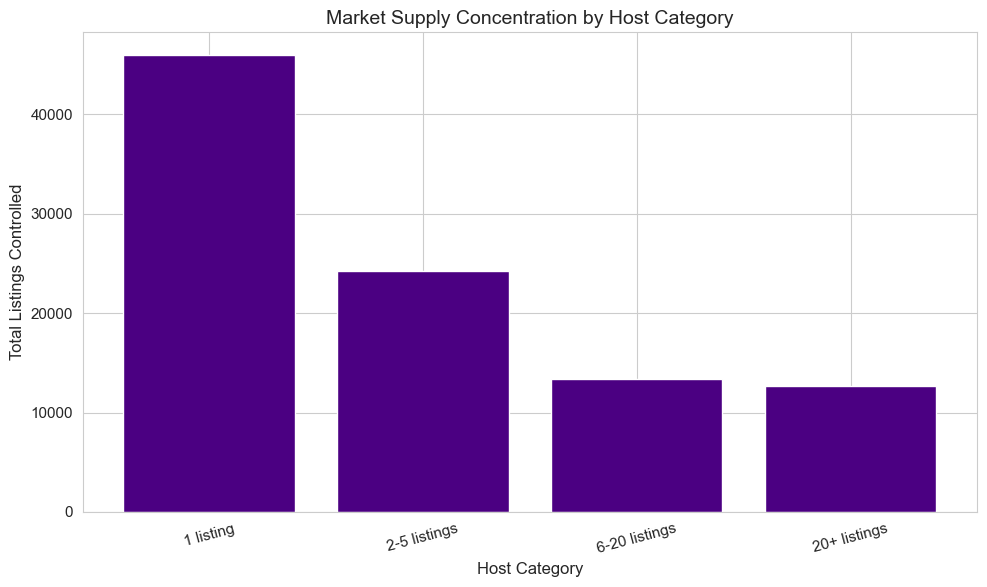

In [43]:
concentration = con.execute("""
    WITH ranked AS (
        SELECT 
            host_id,
            calculated_host_listings_count,
            SUM(calculated_host_listings_count) OVER (ORDER BY calculated_host_listings_count DESC) as cumulative_listings,
            SUM(calculated_host_listings_count) OVER () as total_listings
        FROM dim_host
        WHERE calculated_host_listings_count IS NOT NULL
    )
    SELECT 
        COUNT(*) as host_count,
        MAX(cumulative_listings / total_listings * 100) as cumulative_pct
    FROM ranked
    WHERE cumulative_listings / total_listings <= 0.80
""").df()

print(f" Top hosts controlling 80% of listings:")
print(concentration.to_string(index=False))

# More granular
top_hosts = con.execute("""
    SELECT 
        CASE 
            WHEN calculated_host_listings_count = 1 THEN '1 listing'
            WHEN calculated_host_listings_count BETWEEN 2 AND 5 THEN '2-5 listings'
            WHEN calculated_host_listings_count BETWEEN 6 AND 20 THEN '6-20 listings'
            ELSE '20+ listings'
        END as category,
        COUNT(*) as host_count,
        SUM(calculated_host_listings_count) as total_listings
    FROM dim_host
    WHERE calculated_host_listings_count IS NOT NULL
    GROUP BY category
    ORDER BY total_listings DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_hosts['category'], top_hosts['total_listings'], color='indigo')
ax.set_xlabel('Host Category', fontsize=12)
ax.set_ylabel('Total Listings Controlled', fontsize=12)
ax.set_title('Market Supply Concentration by Host Category', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../reports/figures/10_market_concentration.png', dpi=300, bbox_inches='tight')
plt.show()

### Business interpretation 10 - Market supply concentration by host category

Finding - Single-listing hosts control of 45,000 listings (largest segment), but multi-listing hosts (2-5, 6-20, 20+) collectively control of 52,000 listings, a near-even split with casuals.

What this means?

- London Airbnb is not dominated by commercial operators where casual hosts still hold majority share
- However, the ~52K listings from multi-listing hosts represents a significant commercial presence
- The 2-5 listing tier (~24K) is the "professional-individual" segment — people treating STR as serious side income
- Power law is visible but less extreme than other markets (like NYC or Lisbon)

Actions for market participants,

- Casual hosts (1 listing) - Compete on personal touch, unique properties, authentic experiences
- Semi-pro hosts (2-5 listings) - The growth segment professionalize operations but maintain personal service
- Commercial operators (20+) - Compete on efficiency, dynamic pricing, scale advantages
- Regulators - The 2-tier market (casual vs commercial) may warrant different policy frameworks
- Platform - Should develop features for both segments (community for casuals, tools for commercial)

## Review & demand-side analysis

### Review score distribution

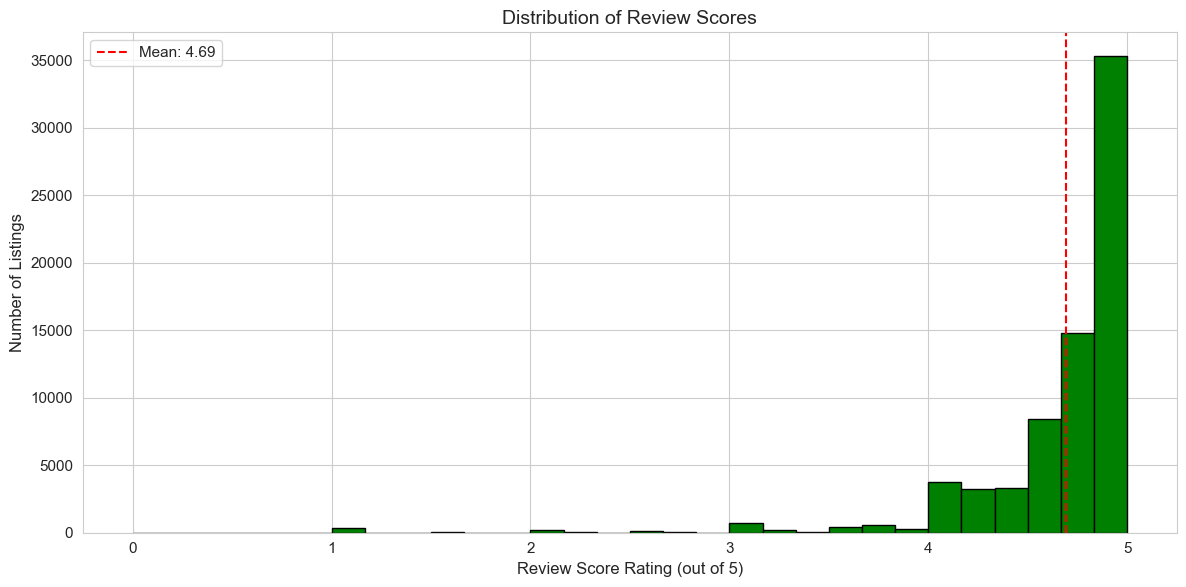

 Saved: 11_review_scores.png

 Mean rating: 4.69/5


In [39]:
scores = con.execute("""
    SELECT review_scores_rating FROM fact_listings
    WHERE review_scores_rating IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(scores['review_scores_rating'], bins=30, color='green', edgecolor='black')
ax.set_xlabel('Review Score Rating (out of 5)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.set_title('Distribution of Review Scores', fontsize=14)
ax.axvline(scores['review_scores_rating'].mean(), color='red', linestyle='--', 
           label=f'Mean: {scores["review_scores_rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/11_review_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: 11_review_scores.png")
print(f"\n Mean rating: {scores['review_scores_rating'].mean():.2f}/5")

### Business interpretation 11 - Rating inflation pattern

Finding - 80%+ of listings score 4.5-5.0 stars. Mean rating is 4.69/5.0. Very few listings score below 4.0.

What this means?
- Classic rating inflation - guests rarely give below-4-star reviews unless extremely disappointed
- This makes it hard to distinguish "good" (4.5) from "excellent" (5.0) listings
- Hosts are highly incentivized to please guests (can lead to biased reviews)

Actions for market participants,
- Guests - Should read review text, not just stars (5-star reviews can mask real issues)
- Platform - Should implement weighted scoring or normalized reviews
- Hosts - Need 4.8+ to be competitive; 4.5 is just "average"

### Reviews vs price scatter

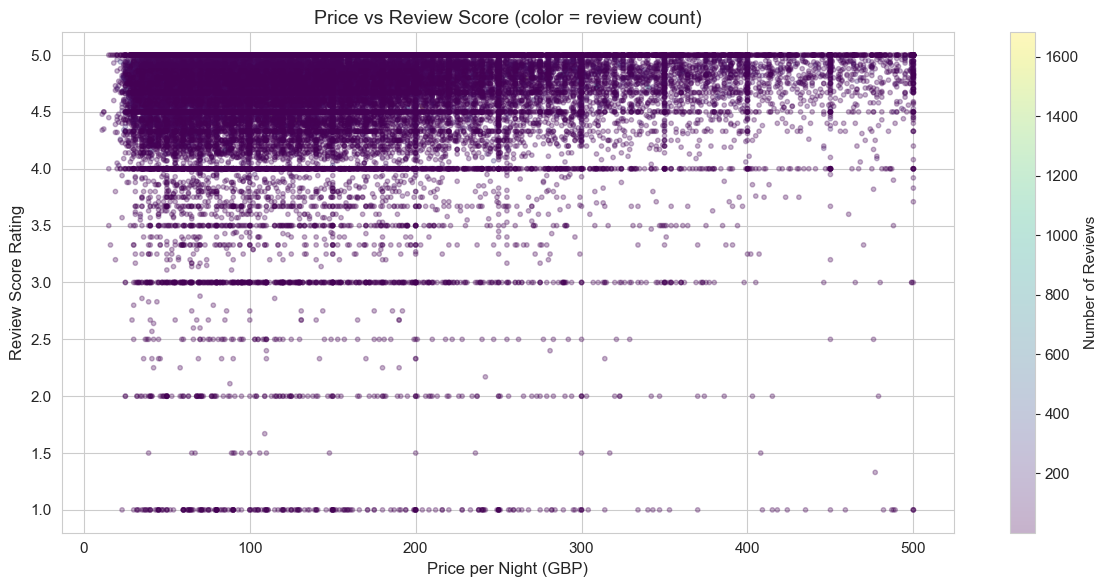

 Saved: 12_price_vs_reviews.png

 High-review listings cluster at 4.5-5.0 stars


In [44]:
review_price = con.execute("""
    SELECT price, number_of_reviews, review_scores_rating
    FROM fact_listings
    WHERE price IS NOT NULL AND price > 0 AND price <= 500
    AND number_of_reviews > 0 AND review_scores_rating IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(review_price['price'], review_price['review_scores_rating'], 
                     c=review_price['number_of_reviews'], cmap='viridis', alpha=0.3, s=10)
ax.set_xlabel('Price per Night (GBP)', fontsize=12)
ax.set_ylabel('Review Score Rating', fontsize=12)
ax.set_title('Price vs Review Score (color = review count)', fontsize=14)
plt.colorbar(scatter, label='Number of Reviews')
plt.tight_layout()
plt.savefig('../reports/figures/12_price_vs_reviews.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: 12_price_vs_reviews.png")
print("\n High-review listings cluster at 4.5-5.0 stars")

### Business interpretation 12 - Price vs review score relationship

Finding - No strong correlation between price and review score. Both cheap and expensive listings can have 4-5 star ratings.

What this means?
- Higher price doesn't guarantee better experience because value perception is independent of cost
- The horizontal bands at 4.0, 4.5, 5.0 suggest these are common "round number" defaults
- Guests don't automatically rate expensive listings higher

Actions for market participants,
- Pricing strategy - Don't price high expecting 5-star reviews; quality matters more
- Guests - Cheap listings can be just as good as expensive ones (read text reviews)
- Platform - Review scores are a quality indicator, not a price proxy

### Sub-dimensions of reviews

 Review Sub-Dimension Averages:
 cleanliness  location  communication  value  overall
        4.65      4.73           4.82   4.62     4.69


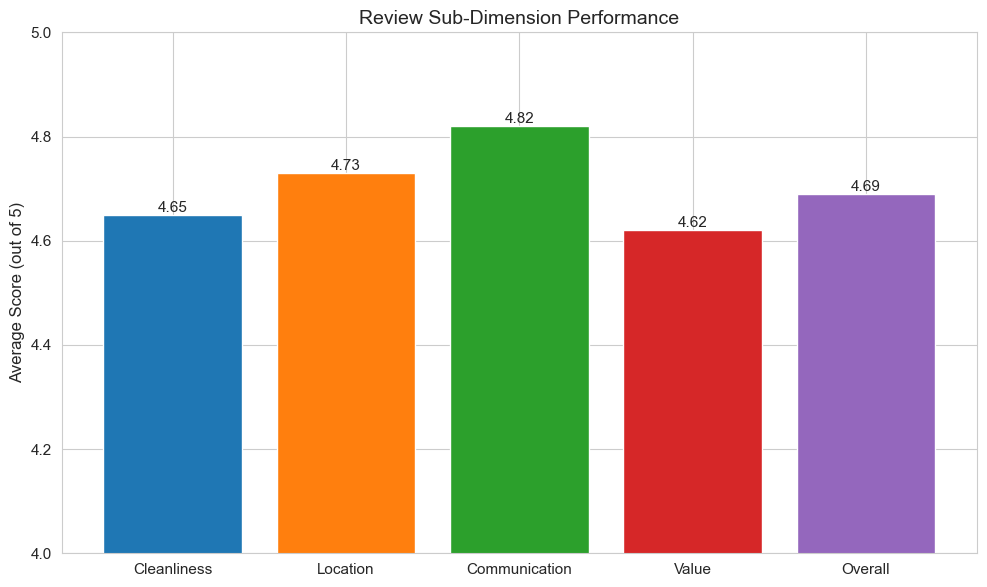

In [28]:
sub_dims = con.execute("""
    SELECT 
        ROUND(AVG(review_scores_cleanliness), 2) as cleanliness,
        ROUND(AVG(review_scores_location), 2) as location,
        ROUND(AVG(review_scores_communication), 2) as communication,
        ROUND(AVG(review_scores_value), 2) as value,
        ROUND(AVG(review_scores_rating), 2) as overall
    FROM fact_listings
    WHERE review_scores_rating IS NOT NULL
""").df()

print(" Review Sub-Dimension Averages:")
print(sub_dims.to_string(index=False))

# Visualization
categories = ['Cleanliness', 'Location', 'Communication', 'Value', 'Overall']
values = [sub_dims['cleanliness'].iloc[0], sub_dims['location'].iloc[0], 
          sub_dims['communication'].iloc[0], sub_dims['value'].iloc[0],
          sub_dims['overall'].iloc[0]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax.set_ylabel('Average Score (out of 5)', fontsize=12)
ax.set_title('Review Sub-Dimension Performance', fontsize=14)
ax.set_ylim(4.0, 5.0)
ax.bar_label(bars, fmt='%.2f')
plt.tight_layout()
plt.savefig('../reports/figures/13_review_subdimensions.png', dpi=300, bbox_inches='tight')
plt.show()

### Business interpretation 13 - Review sub-dimension analysis

Finding - Communication scores highest (4.82), followed by Location (4.73), then Cleanliness (4.65) and Value (4.62) tied at the bottom. Overall average is 4.69.

What this means?

- Hosts excel at communication (4.82) most likely due to platform messaging tools and responsiveness expectations
- Location is a strength (4.73) where guests generally get what they expect
- Cleanliness is a weak point (4.65). The #1 operational issue for STR properties
- Value is the weakest (4.62). Guests feel they're not getting enough for what they pay
- The 0.20-point gap between best (Communication) and worst (Value) is meaningful at scale

Actions for market participants,

- Hosts - Invest in cleaning services and quality control for highest ROI improvement area
- Platform - Should create a "cleanliness verified" badge as cleanliness drives satisfaction
- Pricing strategy - Value scores low → don't raise prices without improving quality
- Guests - Read cleanliness reviews carefully because that's where 1-star discrepancies hide

In [45]:
con.close()
print("Connection closed!")

Connection closed!
